# Rossi Meshing Simulation — Analysis

Two sections:

1. **Source Distribution** — sample the source particles via `openmc.lib.sample_external_source` (the actual OpenMC source object loaded from the model), visualised as a 2D spatial projection and binned onto the tally mesh.
2. **Fission Distribution** — load the `fission_radial` tally from the statepoint and plot fissions per source neutron vs. radial shell.

> **Note on source particles:** OpenMC's fixed-source statepoint does not store source positions.  
> `openmc.lib.sample_external_source` samples directly from the live OpenMC source object (loaded from `model.xml`) — equivalent to what the simulation used.  
> Results are cached to `initial_source.h5` so re-running the notebook is fast.

In [4]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import openmc
import openmc.lib
import pandas as pd
import scienceplots

from project.core.rossi_mesh import CORE_RADIUS, N_RADIAL, make_fission_mesh

plt.style.use(["science", "notebook", "grid", "high-vis"])

RESULTS_DIR = Path("../../results/rossi-meshing-simulation").resolve()
FIGURES_DIR = Path("../outputs/figures/rossi_meshing")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

mesh    = make_fission_mesh()
r_edges = np.asarray(mesh.r_grid)
r_mid   = 0.5 * (r_edges[:-1] + r_edges[1:])

print(f"Mesh: {N_RADIAL} equal-volume radial shells, r ∈ [0, {CORE_RADIUS}] cm")
print(f"Results dir: {RESULTS_DIR}")

Mesh: 100 equal-volume radial shells, r ∈ [0, 3.0] cm
Results dir: /home/itay/projects/initiation-project/project/results/rossi-meshing-simulation


## 1. Source Distribution

`openmc.lib.sample_external_source` loads the model from `model.xml` and samples particles
from the exact same source distribution used during transport.  Results are written to
`initial_source.h5` so subsequent runs skip the sampling step.

In [5]:
N_SOURCE_SAMPLES = 1_000_000
source_file = RESULTS_DIR / "initial_source.h5"

if not source_file.exists():
    orig_dir = os.getcwd()
    os.chdir(RESULTS_DIR)
    openmc.lib.init(output=False)
    particles = openmc.lib.sample_external_source(n_samples=N_SOURCE_SAMPLES)
    openmc.lib.finalize()
    os.chdir(orig_dir)
    particles.export_to_hdf5(source_file)
    print(f"Sampled and cached {N_SOURCE_SAMPLES:,} source particles → {source_file.name}")
else:
    print(f"Loading cached source file: {source_file.name}")

df_src = openmc.read_source_file(str(source_file)).to_dataframe()
print(f"Loaded {len(df_src):,} source particles")
df_src.head(3)

Sampled and cached 1,000,000 source particles → initial_source.h5
Loaded 1,000,000 source particles


,x,y,z,u_x,u_y,u_z,E,time,wgt,delayed_group,surf_id,particle
0,0.244140,1.396853,0.293203,0.654222,-0.610218,-0.446797,9.152656e+05,0.0,1.0,0,0,neutron
1,-0.287229,-0.065715,2.287242,-0.586818,-0.795442,-0.151381,9.637110e+05,0.0,1.0,0,0,neutron
2,0.019370,2.538790,-0.480140,0.910962,-0.392247,-0.127635,2.111795e+06,0.0,1.0,0,0,neutron


In [6]:
x = df_src["x"].to_numpy()
y = df_src["y"].to_numpy()
z = df_src["z"].to_numpy()
r = np.sqrt(x**2 + y**2 + z**2)

print(f"Max radius: {r.max():.5f} cm  (should be ≤ {CORE_RADIUS} cm)")
print(f"All inside core: {np.all(r <= CORE_RADIUS + 1e-9)}")

Max radius: 3.00000 cm  (should be ≤ 3.0 cm)
All inside core: True


### 1.1 Spatial distribution — 2D cross-section

Hexbin of the x–z projection (all 1 M particles; hexbin shows local density instead of
solid-ink scatter).  Uniform fill with no gradient confirms the `PowerLaw(0, R, 2)`
radial sampling is correct.

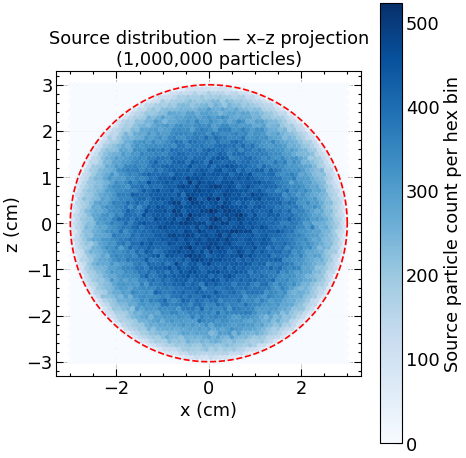

In [9]:
theta_ring = np.linspace(0, 2 * np.pi, 300)

fig, ax = plt.subplots(figsize=(6, 6), dpi=80)
hb = ax.hexbin(x, z, gridsize=60, cmap="Blues", linewidths=0.2)
plt.colorbar(hb, ax=ax, label="Source particle count per hex bin")
ax.plot(
    CORE_RADIUS * np.cos(theta_ring),
    CORE_RADIUS * np.sin(theta_ring),
    "r--", lw=1.5
)
ax.set_aspect("equal")
ax.set_xlabel("x (cm)")
ax.set_ylabel("z (cm)")
ax.set_title(f"Source distribution — x–z projection\n({len(df_src):,} particles)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "source_xz_hexbin.png", dpi=300, bbox_inches="tight")
plt.show()

### 1.2 Source distribution on the tally mesh

Bin the source radii into the same equal-volume shells used for the fission tally.
Equal volume + uniform source → each shell should contain ~the same number of particles.

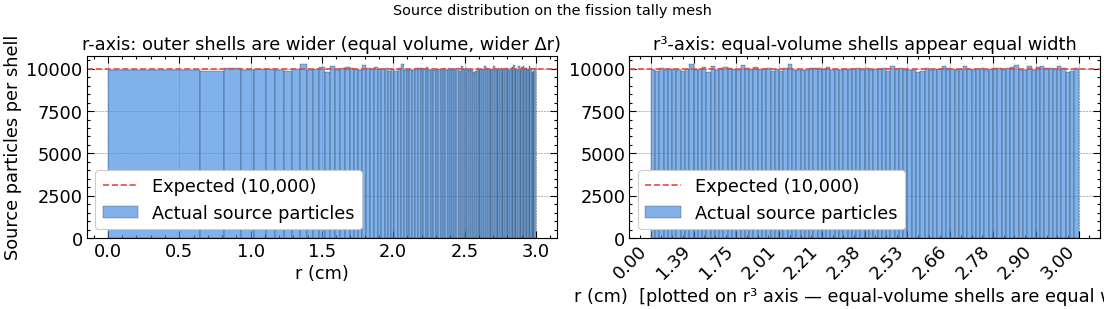

Relative std across shells: 0.966%  (expected ≈ 1.000% from Poisson noise)


In [11]:
shell_counts, _ = np.histogram(r, bins=r_edges)
expected = len(df_src) / N_RADIAL

r3_edges = r_edges**3  # equal-volume shells → equal Δ(r³) → equal bar width on r³ axis

fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=80)

# --- Left: natural r-axis, bars exactly fill each shell (no gaps or overlaps) ---
axes[0].bar(
    r_edges[:-1], shell_counts,
    width=np.diff(r_edges),
    align="edge",
    color="#4A90E2", edgecolor="black", linewidth=0.3, alpha=0.7,
    label="Actual source particles",
)
axes[0].axhline(expected, color="#E24A4A", lw=1.5, linestyle="--",
                label=f"Expected ({expected:,.0f})")
axes[0].set_xlabel("r (cm)")
axes[0].set_ylabel("Source particles per shell")
axes[0].set_title("r-axis: outer shells are wider (equal volume, wider Δr)")
axes[0].legend()

# --- Right: r³-axis, all bars same pixel width ---
# Because shells have equal Δ(r³), every bar spans the same range on this axis.
axes[1].bar(
    r3_edges[:-1], shell_counts,
    width=np.diff(r3_edges),   # all identical
    align="edge",
    color="#4A90E2", edgecolor="black", linewidth=0.3, alpha=0.7,
    label="Actual source particles",
)
axes[1].axhline(expected, color="#E24A4A", lw=1.5, linestyle="--",
                label=f"Expected ({expected:,.0f})")
# Tick marks at every 10th edge, labelled with the actual r value
tick_idx = np.arange(0, N_RADIAL + 1, 10)
axes[1].set_xticks(r3_edges[tick_idx])
axes[1].set_xticklabels([f"{v:.2f}" for v in r_edges[tick_idx]], rotation=45, ha="right")
axes[1].set_xlabel("r (cm)  [plotted on r³ axis — equal-volume shells are equal width]")
axes[1].set_title("r³-axis: equal-volume shells appear equal width")
axes[1].legend()

plt.suptitle("Source distribution on the fission tally mesh", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "source_per_shell.png", dpi=300, bbox_inches="tight")
plt.show()

rel_std = shell_counts.std() / shell_counts.mean()
print(f"Relative std across shells: {rel_std:.3%}  (expected ≈ {1/np.sqrt(expected):.3%} from Poisson noise)")

## 2. Fission Distribution

Load the `fission_radial` mesh tally from the statepoint.  Results are in units of
**fissions per source neutron per shell** (OpenMC normalises fixed-source tallies by
the number of source particles).  Because the shells have equal volume, differences
between shells reflect genuine spatial variation in the fission rate density.

In [12]:
sp      = openmc.StatePoint(str(RESULTS_DIR / "statepoint.1.h5"))
tally   = sp.get_tally(name="fission_radial")
mean    = tally.mean.flatten()      # shape: (N_RADIAL,)
std_dev = tally.std_dev.flatten()

print(f"Tally cells loaded: {len(mean)}  (expected {N_RADIAL})")
print(f"Total fissions / source neutron: {mean.sum():.4e} ± {np.sqrt((std_dev**2).sum()):.4e}")

Tally cells loaded: 100  (expected 100)
Total fissions / source neutron: 1.4864e+01 ± nan


/home/itay/miniforge3/envs/openmc-env/lib/python3.11/site-packages/openmc/tallies.py:549: RuntimeWarning: invalid value encountered in divide
  self._std_dev[nonzero] = np.sqrt((self.sum_sq[nonzero]/n -


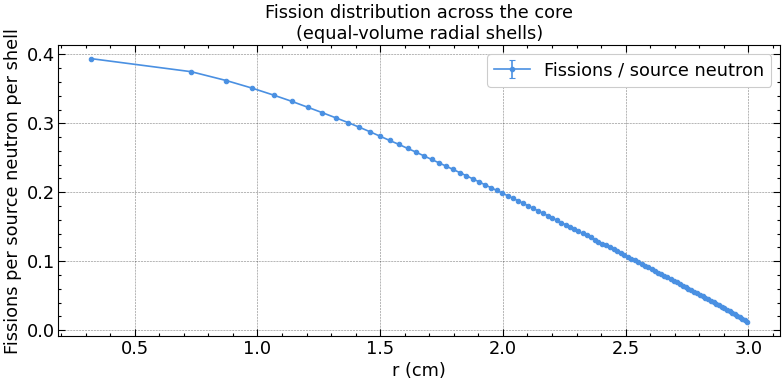

In [13]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=80)
ax.errorbar(
    r_mid, mean, yerr=std_dev,
    fmt="o-", color="#4A90E2", ecolor="#4A90E2",
    capsize=3, lw=1.5, ms=4,
    label="Fissions / source neutron"
)
ax.set_xlabel("r (cm)")
ax.set_ylabel("Fissions per source neutron per shell")
ax.set_title("Fission distribution across the core\n(equal-volume radial shells)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fission_per_shell.png", dpi=300, bbox_inches="tight")
plt.show()